# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset é um conjunto de dados coletado aleatoriamente de uma empresa de telecomunicações iraniana, e tem como objetivo principal a criação de modelos preditivos para identificar a evasão de clientes (churn) em uma operadora móvel.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
# Exibindo as primeiras linhas
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
# Verificando dimensões
print(f"Dimensões: {df.shape}")

Dimensões: (3150, 14)


In [6]:
TARGET_COLUMN = 'Churn' # preencher

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [9]:
df['Churn'].value_counts()

,count
Churn,
0,2655
1,495


/tmp/ipykernel_25387/1937569931.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette='viridis')


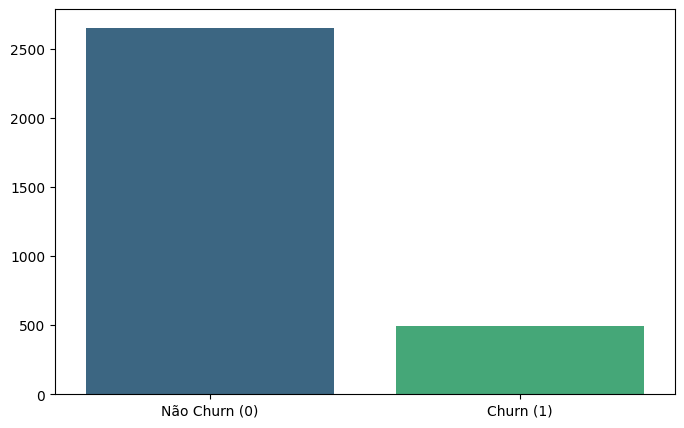

In [10]:
counts = [2655, 495]
labels = ['Não Churn (0)', 'Churn (1)']

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=counts, palette='viridis')

Esse Dataset é desbalanceado, pois a proporção entre as classes está distribuída da seguinte forma: 2655 para não churn e 495 para churn. Essa proporção nos revela que terá  mais exemplos de clientes que permanecem na empresa do que daqueles que saem.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

In [11]:
corr_matrix = df.corr()

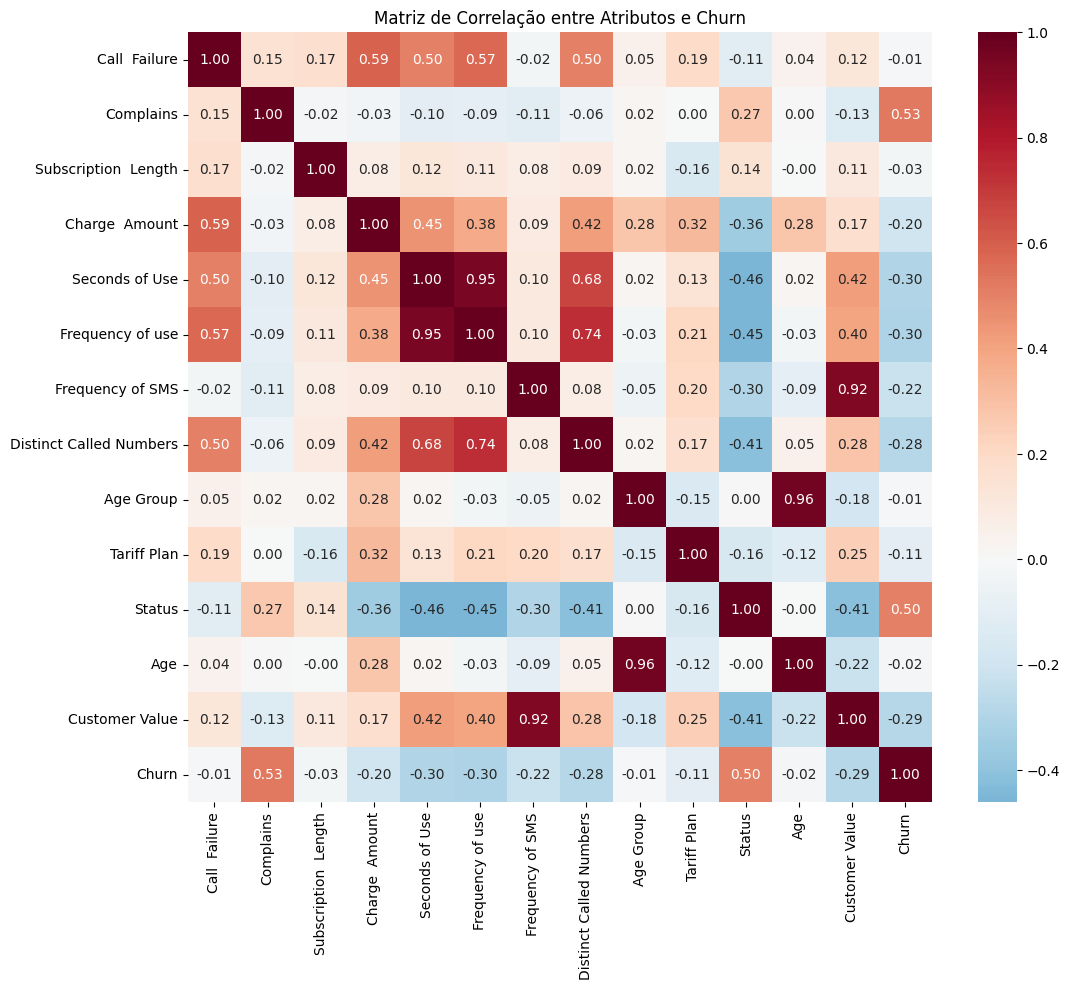

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Matriz de Correlação entre Atributos e Churn')
plt.show()

Os atributos Complains e Status são os preditores mais poderosos neste conjunto de dados.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

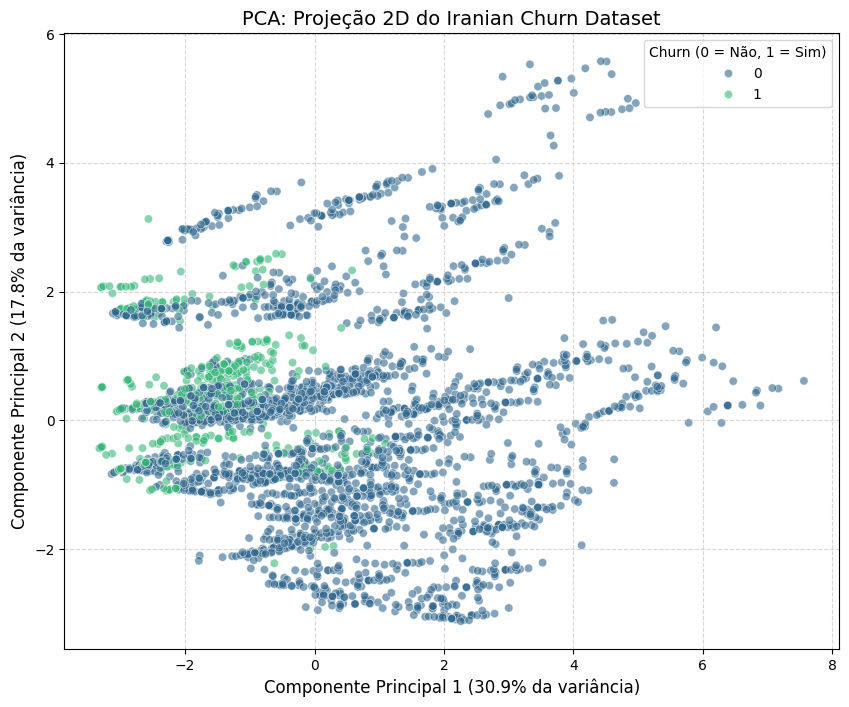

In [13]:
# 1. Separar features (X) e variável alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Padronizar os dados (Média = 0, Variância = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Criar um DataFrame para facilitar a plotagem
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Churn'] = y.values

# Extrair a variância explicada para os rótulos
var_exp = pca.explained_variance_ratio_

# 5. Gerar o Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Churn', palette='viridis', data=df_pca, alpha=0.6)

plt.title('PCA: Projeção 2D do Iranian Churn Dataset', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% da variância)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% da variância)', fontsize=12)
plt.legend(title='Churn (0 = Não, 1 = Sim)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [14]:
# 1. Separar variáveis de entrada (X) e variável alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Dividir os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inicializar o StandardScaler
scaler = StandardScaler()

# 4. Aplicar a padronização: fit_transform no treino e apenas transform no teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensões de Treino: X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Dimensões de Teste: X={X_test_scaled.shape}, y={y_test.shape}")

Dimensões de Treino: X=(2520, 13), y=(2520,)
Dimensões de Teste: X=(630, 13), y=(630,)


Nesse contexto do dataset, é de suma importância transformar e padronizar os dados, já que ele possui atributos em escalas completamente diferentes. O fit é sempre aplicado no treino para evitar o data leakage (vazamento de dados).

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [15]:
# 1. Inicializar o modelo
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# 2. Treinar o modelo utilizando os dados PADRONIZADOS
log_reg.fit(X_train_scaled, y_train)

# 3. Verificar a convergência
iteracoes = log_reg.n_iter_[0]
limite = log_reg.max_iter
convergiu = iteracoes < limite

print(f"O modelo convergiu? {'Sim' if convergiu else 'Não'}")
print(f"Iterações realizadas: {iteracoes} (Limite configurado: {limite})")

O modelo convergiu? Sim
Iterações realizadas: 39 (Limite configurado: 1000)


O papel desse modelo é ser um algoritmo de classificação. Ele é valioso porque calcula a probabilidade de evasão. Durante o treinamento (.fit()), o algoritmo está aprendendo a calcular os coeficientes (pesos) de cada um dos atributos (como Reclamações, Duração da Assinatura, Idade, etc.).

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [18]:
y_probabilidade = log_reg.predict_proba(X_test_scaled)

print("Probabilidades previstas (5 primeiras amostras):")
print(y_probabilidade[:5])

Probabilidades previstas (5 primeiras amostras):
[[8.73776543e-01 1.26223457e-01]
 [9.99172432e-01 8.27567552e-04]
 [9.74710520e-01 2.52894803e-02]
 [9.94280942e-01 5.71905768e-03]
 [9.97311922e-01 2.68807850e-03]]


A coluna 0 representa a probabilidade de o cliente pertencer à Classe 0 (continuar na empresa).
A coluna 1 representa a probabilidade de o cliente pertencer à Classe 1 (cancelar o serviço).
Nesse dataset, a grande maioria das previsões terá valores muito altos na primeira coluna (ex: > 0.85), demonstrando alta confiança de que o cliente não vai dar cancelar o serviço, representando alta confiança.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [19]:
# Pegar apenas as probabilidades da Classe 1 (Churn) - coluna de índice 1
prob_churn = y_proba[:, 1]

# 1. Gerar classificações com os dois limiares
# Se a probabilidade for >= ao limiar, classifica como 1 (Churn), senão 0
y_pred_05 = (prob_churn >= 0.5).astype(int)
y_pred_07 = (prob_churn >= 0.7).astype(int)

# 2. Calcular as matrizes de confusão
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_07 = confusion_matrix(y_test, y_pred_07)

print("Matriz de Confusão (Limiar = 0.5):")
print(f"Verdadeiros Negativos (TN): {cm_05[0, 0]} | Falsos Positivos (FP): {cm_05[0, 1]}")
print(f"Falsos Negativos (FN): {cm_05[1, 0]}   | Verdadeiros Positivos (TP): {cm_05[1, 1]}")

print("\n--------------------------------------------------\n")

print("Matriz de Confusão (Limiar = 0.7):")
print(f"Verdadeiros Negativos (TN): {cm_07[0, 0]} | Falsos Positivos (FP): {cm_07[0, 1]}")
print(f"Falsos Negativos (FN): {cm_07[1, 0]}   | Verdadeiros Positivos (TP): {cm_07[1, 1]}")

Matriz de Confusão (Limiar = 0.5):
Verdadeiros Negativos (TN): 523 | Falsos Positivos (FP): 8
Falsos Negativos (FN): 57   | Verdadeiros Positivos (TP): 42

--------------------------------------------------

Matriz de Confusão (Limiar = 0.7):
Verdadeiros Negativos (TN): 531 | Falsos Positivos (FP): 0
Falsos Negativos (FN): 64   | Verdadeiros Positivos (TP): 35


Aumentar o limiar de 0.5 para 0.7 aumenta a confiabilidade dos seus acertos (quando o modelo diz que é Churn, provavelmente é mesmo), mas faz você "deixar passar" vários casos reais que não atingiram a nota de corte alta.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [20]:
def calcular_metricas(y_true, y_pred, limiar):
    print(f"--- Resultados para Limiar: {limiar} ---")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print(f"Acurácia: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:   {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}\n")

# Calculando e exibindo para ambos os limiares
calcular_metricas(y_test, y_pred_05, 0.5)
calcular_metricas(y_test, y_pred_07, 0.7)

--- Resultados para Limiar: 0.5 ---
Matriz de Confusão:
[[523   8]
 [ 57  42]]
Acurácia: 0.8968
Precisão: 0.8400
Recall:   0.4242
F1-Score: 0.5638

--- Resultados para Limiar: 0.7 ---
Matriz de Confusão:
[[531   0]
 [ 64  35]]
Acurácia: 0.8984
Precisão: 1.0000
Recall:   0.3535
F1-Score: 0.5224



Se a campanha de retenção da operadora for muito cara (ex: dar um iPhone grátis), o limiar de 0.7 é melhor (alta precisão garante que você só gasta com quem realmente ia sair). Mas, se a campanha for barata (ex: enviar um SMS amigável com 10% de desconto), o limiar de 0.5 (ou até menor) é preferível, pois o custo de perder o cliente (Falso Negativo) é muito maior do que o custo de enviar um SMS a mais (Falso Positivo).

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [21]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [ ]:
TARGET_COLUMN = None # preencher

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>